In [1]:
import torch
from torch import nn
import math
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import random
import time
import mesa
import random
random.seed(0)
import warnings
warnings.filterwarnings("ignore")
import sys
import numpy as np

sys.path.append("C:/Users/met48/Desktop/TS-Clustering/mesa-examples-main/mesa-examples-main/examples/forest_fire/") 
from forest_fire import __init__ as forestFireInit
from forest_fire import agent as forestFireAgent
from forest_fire import model as forestFireModel

sys.path.append("C:/Users/met48/Desktop/TS-Clustering/mesa-examples-main/mesa-examples-main/examples/bank_reserves/") 
from bank_reserves import random_walk as bankReservesRandomWalk
from bank_reserves import agents as bankReservesAgent
from bank_reserves import model as bankReservesModel

sys.path.append("C:/Users/met48/Desktop/TS-Clustering/mesa-examples-main/mesa-examples-main/examples/epstein_civil_violence/") 
from epstein_civil_violence import __init__ as epsteinInit
from epstein_civil_violence import agent as epsteinCVAgent
from epstein_civil_violence import model as epsteinCVModel

In [2]:
n_samples = 100

In [3]:
print(mesa.__version__)

1.2.1


# Bank Reserves

In [4]:
inputs = list()
for i in np.arange(n_samples):
    reserve_perc = random.uniform(0,100)
    inputs.append(reserve_perc)

## Actual ABM

In [5]:
br_actual_times = []
for i in np.arange(n_samples):
    start = time.perf_counter()
    bankRes = bankReservesModel.BankReserves(init_people=500, rich_threshold=10, reserve_percent=inputs[i])
    bankRes.run_model()
    results = bankRes.datacollector.get_model_vars_dataframe()
    end = time.perf_counter()
    br_actual_times.append(end-start)

In [6]:
np.mean(br_actual_times)

0.39912304900048184

## Surrogate ABM

In [7]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, condition_dim=1, output_dim=101):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
        self.temporal_smoother = nn.Conv1d(1, 1, kernel_size=9, padding=4)  # keeps shape

    def forward(self, z, conditions):
        x = torch.cat([z, conditions], dim=1)
        out = self.fc(x)
        out = out.unsqueeze(1)  # (B, 1, 252)
        out = self.temporal_smoother(out)
        return out.squeeze(1)

generator = ConditionalGenerator()

In [8]:
br_surrogate_times = []
generator = ConditionalGenerator()
generator.load_state_dict(torch.load("C:/Users/met48/Desktop/ABM-Surrogate/generator_gan_br_ts_128_dupe.pth"))
generator.eval()
with torch.no_grad():
    for i in np.arange(n_samples):
        latent_dim = 100  # or whatever your latent size is
        z = torch.randn(1, latent_dim)
        cond = torch.tensor([[inputs[i]]], dtype=torch.float32)
        start = time.perf_counter()
        generated_samples = generator(z, cond)  # (n_samples, 252)
        end = time.perf_counter()
        br_surrogate_times.append(end-start)

In [9]:
np.mean(br_surrogate_times)

0.00014058499975362791

# Epstein

In [10]:
inputs = list()
for i in np.arange(n_samples):
    cit_dens = random.uniform(0.5, 1)
    cop_dens = random.uniform(0, 1-cit_dens)
    leg = random.uniform(0, 1)
    inputs.append([cit_dens, cop_dens, leg])

## Actual ABM

In [11]:
ecv_actual_times = []
for i in np.arange(n_samples):
    start = time.perf_counter()
    bankRes = epsteinCVModel.EpsteinCivilViolence(citizen_density=inputs[i][0], cop_density=inputs[i][1], citizen_vision=5, cop_vision=5, legitimacy=inputs[i][2], max_jail_term=30, active_threshold = 0.1, arrest_prob_constant = 2.3, movement=True, max_iters=250)
    bankRes.run_model()
    results = bankRes.datacollector.get_model_vars_dataframe()
    end = time.perf_counter()
    ecv_actual_times.append(end-start)

In [12]:
np.mean(ecv_actual_times)

18.019196323000507

## Surrogate ABM

In [13]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, condition_dim=3, output_dim=252):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
        self.temporal_smoother = nn.Conv1d(1, 1, kernel_size=5, padding=2)  # keeps shape

    def forward(self, z, conditions):
        x = torch.cat([z, conditions], dim=1)
        out = self.fc(x)
        out = out.unsqueeze(1)  # (B, 1, 252)
        out = self.temporal_smoother(out)
        return out.squeeze(1)

In [14]:
ecv_surrogate_times = []
generator = ConditionalGenerator()
generator.load_state_dict(torch.load("C:/Users/met48/Desktop/ABM-Surrogate/generator_gan_ecv_ts_128.pth"))
generator.eval()
with torch.no_grad():
    for i in np.arange(n_samples):
        latent_dim = 100  # or whatever your latent size is
        z = torch.randn(1, latent_dim)
        cond = torch.tensor([[inputs[i]]], dtype=torch.float32).view(1, -1)
        start = time.perf_counter()
        generated_samples = generator(z, cond)  # (n_samples, 252)
        end = time.perf_counter()
        ecv_surrogate_times.append(end-start)

In [15]:
np.mean(ecv_surrogate_times)

0.0001334389996191021

# Forest Fire

In [4]:
inputs = list()
for i in np.arange(n_samples):
    density = random.uniform(0, 1)
    inputs.append(density)

## Actual ABM

In [5]:
ff_actual_times = []
for i in np.arange(n_samples):
    start = time.perf_counter()
    fire = forestFireModel.ForestFire(width=100, height=100, density=inputs[i])
    fire.run_model()
    results = fire.datacollector.get_model_vars_dataframe()
    end = time.perf_counter()
    ff_actual_times.append(end-start)

In [6]:
np.mean(ff_actual_times)

0.17304410400014603

## Surrogate ABM

In [7]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, condition_dim=1, output_dim=155):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
        self.temporal_smoother = nn.Conv1d(1, 1, kernel_size=9, padding=4)  # keeps shape

    def forward(self, z, conditions):
        x = torch.cat([z, conditions], dim=1)
        out = self.fc(x)
        out = out.unsqueeze(1)  # (B, 1, 252)
        out = self.temporal_smoother(out)
        return out.squeeze(1)

In [8]:
ff_surrogate_times = []
generator = ConditionalGenerator()
generator.load_state_dict(torch.load("C:/Users/met48/Desktop/ABM-Surrogate/generator_gan_ff_ts_128_9.pth"))
generator.eval()
with torch.no_grad():
    for i in np.arange(n_samples):
        latent_dim = 100  # or whatever your latent size is
        z = torch.randn(1, latent_dim)
        cond = torch.tensor([[inputs[i]]], dtype=torch.float32)
        start = time.perf_counter()
        generated_samples = generator(z, cond)  # (n_samples, 252)
        end = time.perf_counter()
        ff_surrogate_times.append(end-start)

In [9]:
np.mean(ff_surrogate_times)

0.00014080100052524358

In [19]:
generated_samples

tensor([[0.0014, 0.0079, 0.0204, 0.0408, 0.0326, 0.0687, 0.0658, 0.0791, 0.1123,
         0.0913, 0.1271, 0.1383, 0.1378, 0.1636, 0.1660, 0.2031, 0.2082, 0.2456,
         0.2452, 0.2737, 0.2739, 0.2850, 0.3245, 0.2991, 0.3315, 0.3598, 0.3582,
         0.3776, 0.4119, 0.4122, 0.4320, 0.4517, 0.4722, 0.4734, 0.5055, 0.4890,
         0.5057, 0.5093, 0.5005, 0.5086, 0.4796, 0.5086, 0.4832, 0.5176, 0.5023,
         0.5134, 0.5313, 0.5054, 0.5051, 0.5012, 0.4817, 0.4876, 0.4906, 0.5056,
         0.5024, 0.5344, 0.5317, 0.5199, 0.5282, 0.5331, 0.5163, 0.5229, 0.5282,
         0.5226, 0.5295, 0.5277, 0.5370, 0.5137, 0.5393, 0.5322, 0.5195, 0.5419,
         0.5295, 0.5222, 0.5565, 0.5134, 0.5504, 0.5309, 0.5297, 0.5434, 0.5151,
         0.5304, 0.5218, 0.4978, 0.5380, 0.5153, 0.5071, 0.5508, 0.5277, 0.5251,
         0.5429, 0.5362, 0.5134, 0.5199, 0.5320, 0.4994, 0.5310, 0.5192, 0.5378,
         0.5351, 0.5423, 0.5508, 0.5288, 0.5551, 0.5383, 0.5247, 0.5334, 0.5273,
         0.5286, 0.5223, 0.5

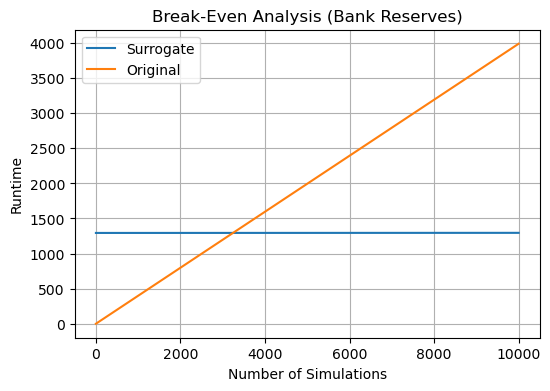

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (you can change these)
a = 1294.0267
b = 0.00014
c = 0.39912

# Generate x values
x = np.linspace(0, 10000, 10000)

# Compute y values
y1 = a + b * x
y2 = c * x

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y1, label='Surrogate')
plt.plot(x, y2, label='Original')

# Labels and legend
plt.xlabel('Number of Simulations')
plt.ylabel('Runtime')
plt.title('Break-Even Analysis (Bank Reserves)')
plt.legend()
plt.grid(True)

plt.savefig('br_breakeven.png')

In [29]:
x = a / (c - b)
print(x)

3243.337260013033


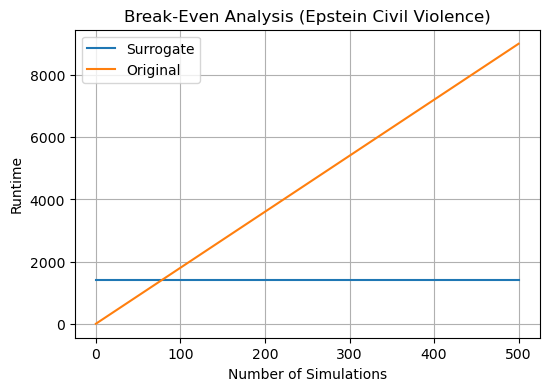

In [30]:
# Parameters (you can change these)
a = 1399.6680
b = 0.00013
c = 18.01920

# Generate x values
x = np.linspace(0, 500, 500)

# Compute y values
y1 = a + b * x
y2 = c * x

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y1, label='Surrogate')
plt.plot(x, y2, label='Original')

# Labels and legend
plt.xlabel('Number of Simulations')
plt.ylabel('Runtime')
plt.title('Break-Even Analysis (Epstein Civil Violence)')
plt.legend()
plt.grid(True)

plt.savefig('ecv_breakeven.png')

In [31]:
x = a / (c - b)
print(x)

77.67703882608812


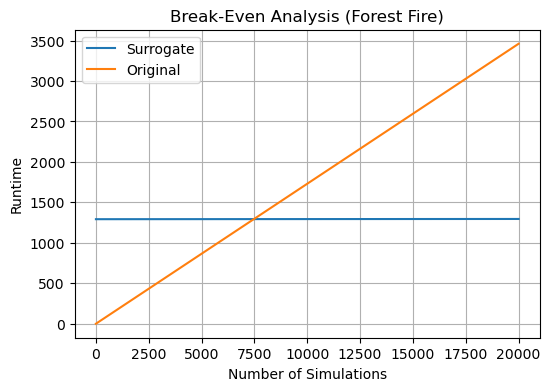

In [32]:
# Parameters (you can change these)
a = 1291.9864
b = 0.00014
c = 0.17304

# Generate x values
x = np.linspace(0, 20000, 20000)

# Compute y values
y1 = a + b * x
y2 = c * x

# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, y1, label='Surrogate')
plt.plot(x, y2, label='Original')

# Labels and legend
plt.xlabel('Number of Simulations')
plt.ylabel('Runtime')
plt.title('Break-Even Analysis (Forest Fire)')
plt.legend()
plt.grid(True)

plt.savefig('ff_breakeven.png')

In [33]:
x = a / (c - b)
print(x)

7472.448814343551
